In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import find_peaks
ET_FILE = "triple_sensor_session_ET.npz"
YM_FILE = "triple_sensor_session_YM.npz"


In [88]:
from scipy.signal import find_peaks
import numpy as np

t = timestamps_vernier.astype(float)
x = resp_vals.squeeze().astype(float)

# basic cleanup
m = np.isfinite(t) & np.isfinite(x)
t = t[m]
x = x[m]

# raw peak detection (tune these!)
peaks, props = find_peaks(
    x,
    prominence=np.nanstd(x)*0.2,   # adjust up/down
    distance=10                   # adjust based on sampling rate
)

tp = t[peaks]
dt = np.diff(tp)

f_avg_hz = 1.0 / np.mean(dt)
f_med_hz = 1.0 / np.median(dt)

print("Raw peak avg freq (Hz):", f_avg_hz)
print("Raw peak median freq (Hz):", f_med_hz)
print("Raw peak avg rate (per min):", 60*f_avg_hz)

# optional: quick sanity check
print("Num peaks:", len(peaks))
print("Mean peak interval (s):", np.mean(dt))

Raw peak avg freq (Hz): 0.29332227512619513
Raw peak median freq (Hz): 0.3421888053467001
Raw peak avg rate (per min): 17.599336507571707
Num peaks: 87
Mean peak interval (s): 3.4092194313226742


['VernieRespiration', 'TobiiEyeTracker', 'PolarHeartRate']


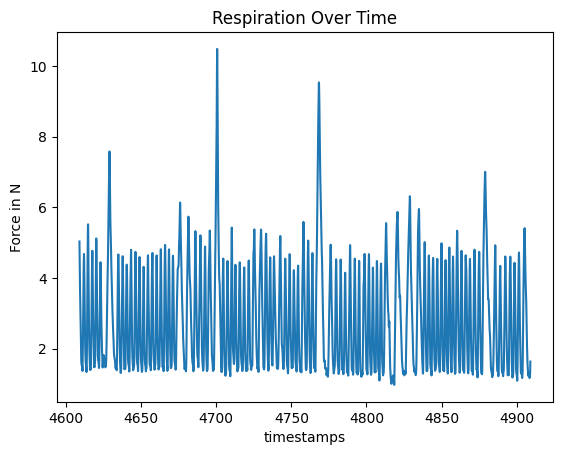

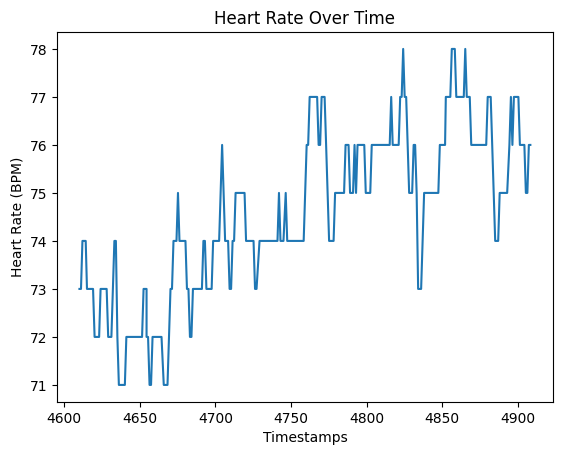

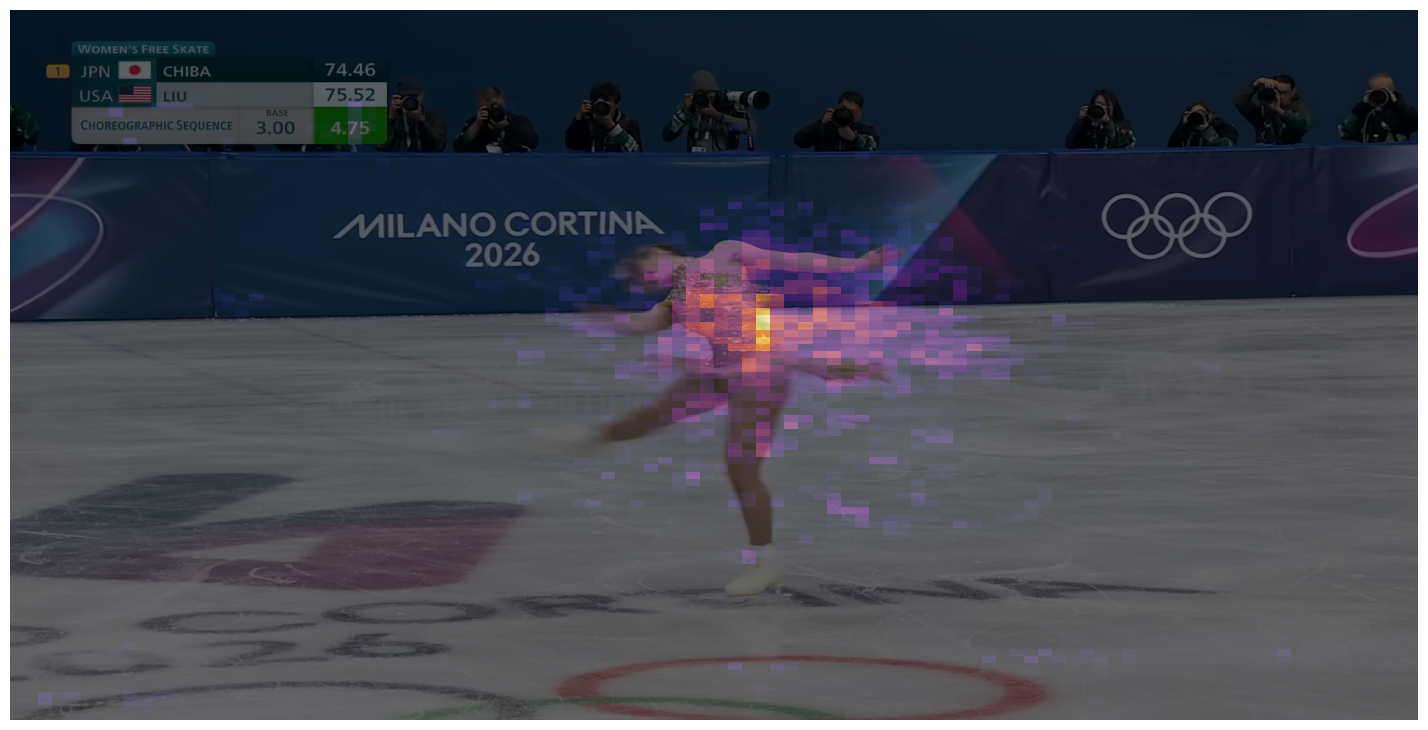

In [91]:
with np.load(ET_FILE, allow_pickle=True) as data:
    print(data.files)
    vernier = data['VernieRespiration'].item() 
    tobii = data['TobiiEyeTracker'].item()
    polar = data['PolarHeartRate'].item()

    #====== RESPIRATORY DATA ======#
    resp_vals = np.array(vernier["data"], dtype=np.float32)
    resp_vals = resp_vals[:, 0]   # make it 1D
    timestamps_vernier = np.array(vernier["timestamps"], dtype=np.float32)

    plt.plot(timestamps_vernier, resp_vals)
    plt.ylabel("Force in N")
    plt.xlabel("timestamps")
    plt.title("Respiration Over Time")

    #====== HR DATA ======#

    hr_vals = np.array(polar["data"], dtype=np.float32)
    timestamps_polar= np.array(polar["timestamps"], dtype=np.float32)
    
    plt.figure()

    plt.plot(timestamps_polar, hr_vals[:,0])

    plt.xlabel("Timestamps")
    plt.ylabel("Heart Rate (BPM)")
    plt.title("Heart Rate Over Time")

    plt.show()


    #====== EYE-TRACKING DATA ======#
    eye = np.array(tobii["data"], dtype=np.float32)
    timestamps_tobii = np.array(tobii["timestamps"], dtype=np.float32)

    x = eye[:, 0]
    y = eye[:, 1]
    x_isValid = eye[:, 4]
    y_isValid = eye[:, 5]

    
    mask = (x_isValid == 1) & (y_isValid == 1)
    x = x[mask]
    y = y[mask]

    W_PX, H_PX = 1408, 710

    x_px = x * W_PX
    y_px = y * H_PX

    img = plt.imread("frame.png")

    fig = plt.figure(figsize=(W_PX/100, H_PX/100))
    ax = fig.add_axes([0, 0, 1, 1])

    ax.imshow(img, extent=[0, W_PX, H_PX, 0])

    ax.hist2d(
        x_px, y_px,
        bins=100,
        range=[[0, W_PX], [0, H_PX]],
        cmap="inferno",
        alpha=0.6
    )

    ax.set_xlim(0, W_PX)
    ax.set_ylim(H_PX, 0)
    ax.set_axis_off()

    plt.show()





['TobiiEyeTracker', 'PolarHeartRate', 'VernieRespiration']


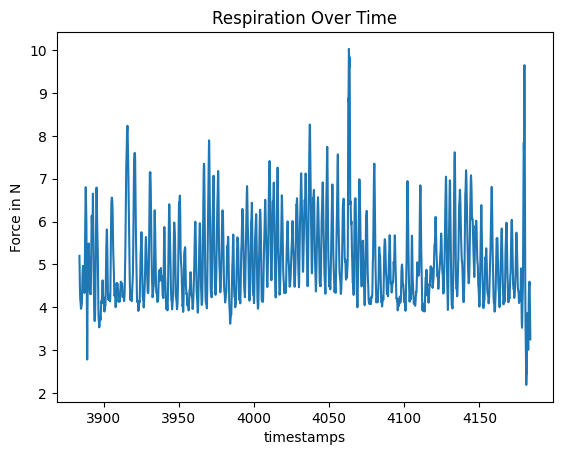

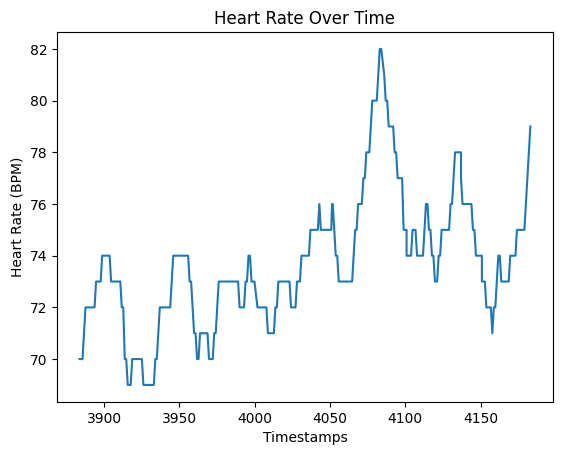

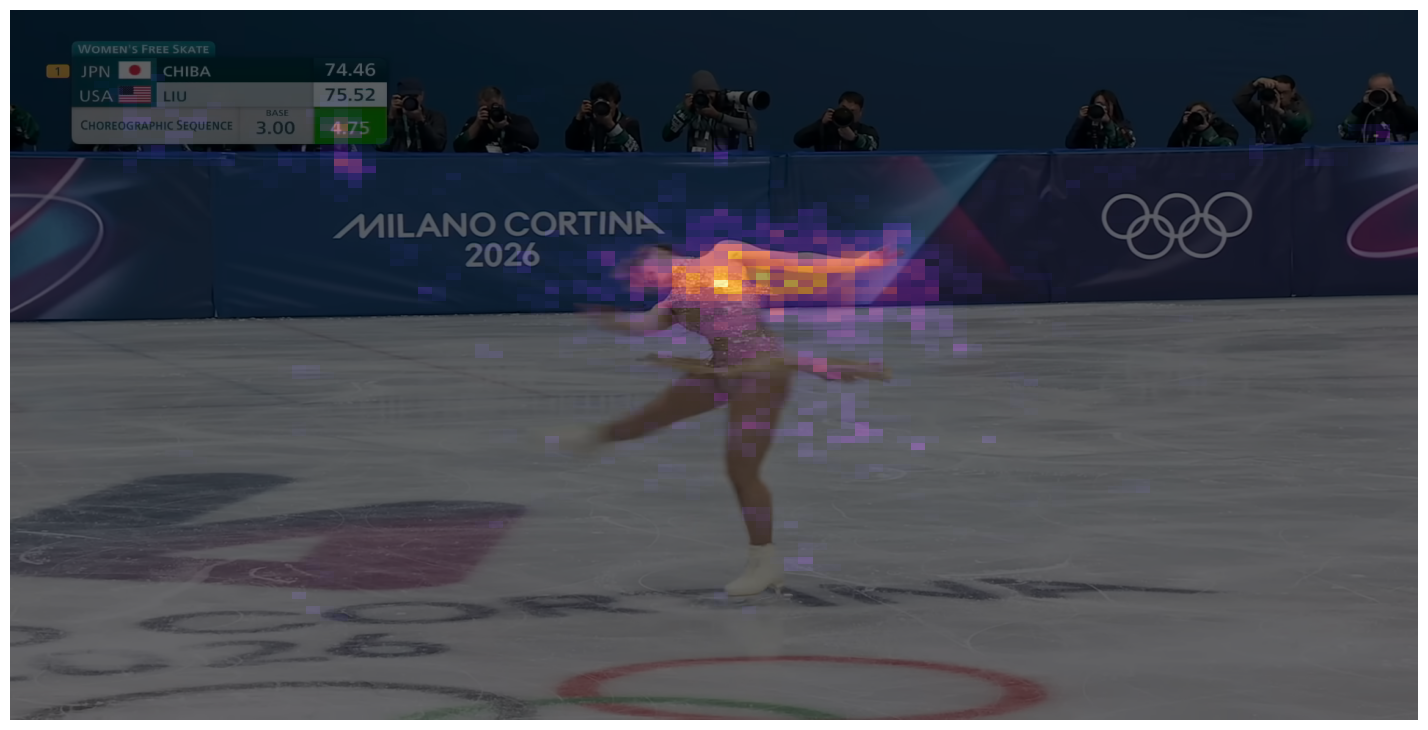

In [93]:
with np.load(YM_FILE, allow_pickle=True) as data:
    print(data.files)
    vernier = data['VernieRespiration'].item() 
    tobii = data['TobiiEyeTracker'].item()
    polar = data['PolarHeartRate'].item()

    #====== RESPIRATORY DATA ======#
    resp_vals = np.array(vernier["data"], dtype=np.float32)
    resp_vals = resp_vals[:, 0]   # make it 1D
    timestamps_vernier = np.array(vernier["timestamps"], dtype=np.float32)

    plt.plot(timestamps_vernier, resp_vals)
    plt.ylabel("Force in N")
    plt.xlabel("timestamps")
    plt.title("Respiration Over Time")

    #====== HR DATA ======#

    hr_vals = np.array(polar["data"], dtype=np.float32)
    timestamps_polar= np.array(polar["timestamps"], dtype=np.float32)
    
    plt.figure()

    plt.plot(timestamps_polar, hr_vals[:,0])

    plt.xlabel("Timestamps")
    plt.ylabel("Heart Rate (BPM)")
    plt.title("Heart Rate Over Time")

    plt.show()


    #====== EYE-TRACKING DATA ======#
    eye = np.array(tobii["data"], dtype=np.float32)
    timestamps_tobii = np.array(tobii["timestamps"], dtype=np.float32)

    x = eye[:, 0]
    y = eye[:, 1]
    x_isValid = eye[:, 4]
    y_isValid = eye[:, 5]

    
    mask = (x_isValid == 1) & (y_isValid == 1)
    x = x[mask]
    y = y[mask]

    W_PX, H_PX = 1408, 710

    x_px = x * W_PX
    y_px = y * H_PX

    img = plt.imread("frame.png")

    fig = plt.figure(figsize=(W_PX/100, H_PX/100))
    ax = fig.add_axes([0, 0, 1, 1])

    ax.imshow(img, extent=[0, W_PX, H_PX, 0])

    ax.hist2d(
        x_px, y_px,
        bins=100,
        range=[[0, W_PX], [0, H_PX]],
        cmap="inferno",
        alpha=0.6
    )

    ax.set_xlim(0, W_PX)
    ax.set_ylim(H_PX, 0)
    ax.set_axis_off()

    plt.show()

